In [1]:
import torch 
import torch_geometric
from torch_geometric.data import Data, DataLoader, InMemoryDataset
import numpy as np
import matplotlib.pyplot as plt
import os
from torch import nn, Tensor
from sklearn.datasets import make_moons
import torch.nn.functional as F
from torch.autograd import grad
from torchdiffeq import odeint
from torch.utils.data import  TensorDataset
from torchvision import datasets, transforms
import math

C:\Users\nasso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\nasso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch_cluster\_grid_cuda.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
C:\Users\nasso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\nasso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCach

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from torch.optim.lr_scheduler import ReduceLROnPlateau

# for cleaner look (set your theme to dark mode)
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#1E1E1E'
plt.rcParams['axes.facecolor'] = '#1E1E1E'
plt.rcParams['savefig.facecolor'] = '#1E1E1E'

from tqdm import tqdm
from IPython.display import Image

In [3]:
trajectories = [np.load(f"../../data/boids/raw/{f}") for f in os.listdir("../../data/boids/raw") if f.endswith(".npy")]
print(len(trajectories))

26


In [4]:
print("Single trajectory shape:")
print(trajectories[0].shape)
print("The axes and their cardinalities; (Timesteps:1000, Boids:25, (Position X, Position Y, Velocity x, Velocity y):4)")

Single trajectory shape:
(1000, 25, 4)
The axes and their cardinalities; (Timesteps:1000, Boids:25, (Position X, Position Y, Velocity x, Velocity y):4)


In [5]:
# Print the mean, std, min and max of the boid positions, velocities
positions = np.array([t[:, :, :2] for t in trajectories])
velocities = np.array([t[:, :, 2:] for t in trajectories])

print("Position mean, std, min, max:")
# Round to 2 decimal places
print(round(np.mean(positions),2), round(np.std(positions),2), round(np.min(positions), 2), round(np.max(positions), 2))
print()
print("Velocity mean, std, min, max:")
# Round to 2 decimal places
print(round(np.mean(velocities),2), round(np.std(velocities),2), round(np.min(velocities), 2), round(np.max(velocities), 2))

Position mean, std, min, max:
500.32 290.61 0.0 1000.0

Velocity mean, std, min, max:
-0.35 2.96 -6.0 6.0


In [6]:
def plot_state(trajectory, timestep):
    fig, ax = plt.subplots()
    # Plot dots for the boids
    ax.scatter(trajectory[timestep, :, 0], trajectory[timestep, :, 1])
    # plot the boid velocities as arrows
    for i in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        ax.arrow(trajectory[timestep, i, 0], trajectory[timestep, i, 1], trajectory[timestep, i, 2]*5, trajectory[timestep, i, 3]*5)
    return ax

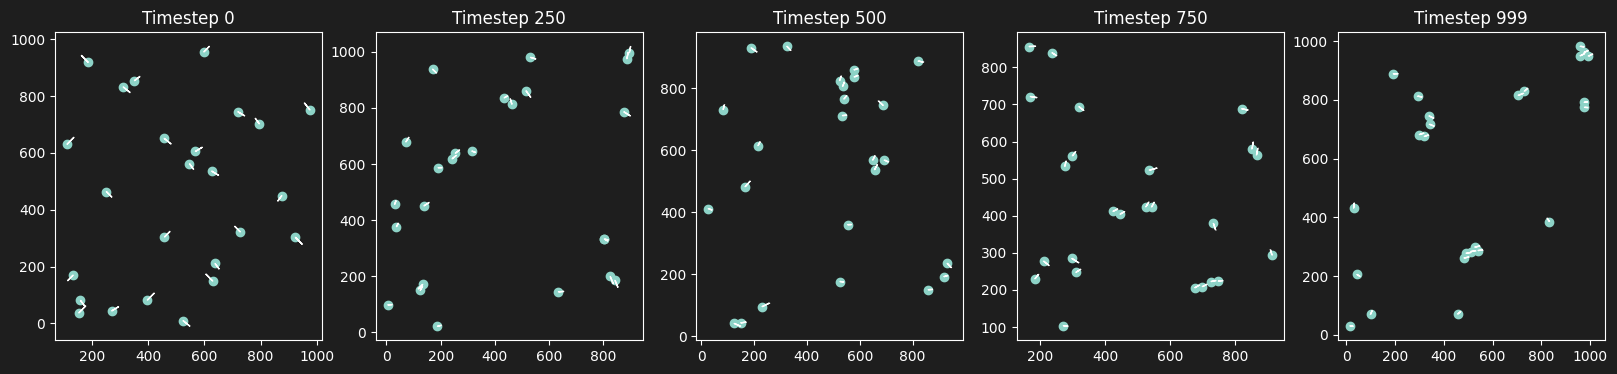

In [7]:
# Plot timesteps 0, 250, 500, 750, 999 for the first trajectory
trajectory = trajectories[0]
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, t in enumerate([0, 250, 500, 750, 999]):
    axs[i].set_title(f"Timestep {t}")
    # Plot dots for the boids
    axs[i].scatter(trajectory[t, :, 0], trajectory[t, :, 1])
    # plot the boid velocities as arrows
    for j in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        axs[i].arrow(trajectory[t, j, 0], trajectory[t, j, 1], trajectory[t, j, 2]*5, trajectory[t, j, 3]*5)
plt.show()

Dataset creation

In [8]:
class Boids_Dataset(InMemoryDataset):
    def __init__(self, raw_data_path, processed_data_path, root=None,
                 transform=None, pre_transform=None, post_transform=None,
                 solution_idx_range=(0, 25), timesteps=1000,
                 processed_file_name="AR1_Boids_Equivariant.pt", L=1000):
        self.raw_data_path = raw_data_path
        self.processed_data_path = processed_data_path
        self.solution_idx_range = solution_idx_range
        self.timesteps = timesteps
        self.processed_file_name = processed_file_name
        self.pre_transform = pre_transform
        self.transform = transform
        self.post_transform = post_transform
        self.L = L
        super(Boids_Dataset, self).__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def processed_file_names(self):
        return [self.processed_file_name]

    @property
    def raw_file_names(self):
        return [pfn for pfn in os.listdir(self.raw_data_path)
                if (self.solution_idx_range[0] <= int(pfn.split("_")[-1][:-4]) < self.solution_idx_range[1])]

    def download(self):
        pass

    def process(self):
        max_forward_steps = 5
        data_list = []
        all_init_positions = []   
        vmax = 0.0
        for raw_path in self.raw_file_names:
            trajectory = np.load(os.path.join(self.raw_data_path, raw_path))  
            vels = trajectory[:, :, 2:]  
            vmax = max(vmax, np.abs(vels).max())
        if vmax == 0:
            vmax = 1.0

        print(f"[Normalization] Using L={self.L}, vmax={vmax:.4f}")

        for raw_path in self.raw_file_names:
            trajectory = np.load(os.path.join(self.raw_data_path, raw_path))

            init_pos = torch.tensor(trajectory[0, :, :2], dtype=torch.float)  
            all_init_positions.append(init_pos)

            for t in range(trajectory.shape[0] - max_forward_steps):
                # current state
                pos_t = torch.tensor(trajectory[t, :, :2], dtype=torch.float) / self.L
                vel_t = torch.tensor(trajectory[t, :, 2:], dtype=torch.float) / vmax
                x = torch.cat([pos_t, vel_t], dim=-1) 

                pos_next = torch.tensor(trajectory[t+1, :, :2], dtype=torch.float) / self.L
                vel_next = torch.tensor(trajectory[t+1, :, 2:], dtype=torch.float) / vmax
                y = torch.cat([pos_next, vel_next], dim=-1)

                N = pos_t.shape[0]
                edge_index = torch.combinations(torch.arange(N), r=2, with_replacement=False).T
                edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
                senders, receivers = edge_index

                # relative displacement as edge attribute
                rel_disp = pos_t[receivers] - pos_t[senders]
                rel_disp = rel_disp - torch.round(rel_disp)
                edge_attr = rel_disp

                data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
                data_list.append(data)

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])

        all_init_positions = torch.stack(all_init_positions)   
        torch.save(all_init_positions, os.path.join(self.processed_data_path,
                                                    "positions_" + self.processed_file_name))
        print(f"Saved initial positions: {all_init_positions.shape}")
        
    def __getitem__(self, idx):
        return self.get(idx)
    
    def __repr__(self):
        return f'{self.__class__.__name__}({len(self)})'

In [9]:
train_dataset = Boids_Dataset(raw_data_path="../../data/boids/raw/", processed_data_path="../../data/boids/processed/", root="../../data/boids/", solution_idx_range=(0, 15), timesteps=1000, processed_file_name="Boids4.pt")
validation_dataset = Boids_Dataset(raw_data_path="../../data/boids/raw/", processed_data_path="../../data/boids/processed/", root="../../data/boids/", solution_idx_range=(16, 25), timesteps=1000, processed_file_name="VAL_Boids4.pt")

print(train_dataset)
print(validation_dataset)


data_0 = train_dataset[0]
print(data_0)
print(data_0.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_0.x[0,:])

Boids_Dataset(14925)
Boids_Dataset(8955)
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7190,  0.7450,  0.8333, -0.5000])


In [10]:
print(data_0.y[0,:])

data_1 = train_dataset[1]
print(data_1)
print(data_1.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_1.x[0,:])

print(data_1.y[0,:])

data_2 = train_dataset[2]
print(data_2)
print(data_2.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_2.x[0,:])

tensor([ 0.7240,  0.7420,  0.8333, -0.5000])
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7240,  0.7420,  0.8333, -0.5000])
tensor([ 0.7290,  0.7390,  0.8333, -0.5000])
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7290,  0.7390,  0.8333, -0.5000])


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

GNN Model

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import MessagePassing


class EdgeGNNVectorField_X0Conditioned(MessagePassing):
    """
    Conditional Flow Matching GNN conditioned on the x0.
    Learns vθ(x_t, x0, t): vector field moving base → data.
    """

    def __init__(self, hidden_dim=64, n_layers=2):
        super().__init__(aggr='mean')
        self.n_layers = n_layers

        self.edge_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(4, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(n_layers)
        ])

        self.node_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim + 4 + 4 + 1, hidden_dim),  # [agg, x_t, x₀, t]
                nn.ReLU(),
                nn.Linear(hidden_dim, 4)
            ) for _ in range(n_layers)
        ])

    def forward(self, x_t, x_0, edge_index, t):
        """
        Args:
            x_t: [N, 4] current (intermediate) state
            x_0: [N, 4] (conditioning) state
            edge_index: [2, E]
            t: [N, 1] or scalar, time ∈ [0, 1]
        Returns:
            v_pred: [N, 4]
        """
        edge_attr = self.compute_edge_attr(x_t, edge_index)
        h = x_t

        for i in range(self.n_layers):
            edge_msg = self.edge_mlps[i](edge_attr)
            agg_msg = self.propagate(edge_index, x=h, edge_attr=edge_msg)
            node_in = torch.cat([agg_msg, h, x_0, t], dim=-1)
            h = self.node_mlps[i](node_in)

        return h

    def message(self, x_j, edge_attr):
        return edge_attr

    def compute_edge_attr(self, x, edge_index, L=1.0):
        row, col = edge_index
        pos = x[:, :2]
        vel = x[:, 2:]
        rel_pos = pos[col] - pos[row]
        rel_pos = rel_pos - L * torch.round(rel_pos / L)
        rel_vel = vel[col] - vel[row]
        return torch.cat([rel_pos, rel_vel], dim=-1)

    @torch.no_grad()
    def generate(self, x0, edge_index, n_steps=50, dt=0.02, sigma=0.1, L=1.0):
        """
        Generation from random noise → data (integrate reverse direction).

        Args:
            x0: start conditioning sample [N, 4]
            edge_index: graph edges
            n_steps: Euler integration steps
            dt: integration step size
            sigma: noise scaling
            L: periodic box length
        """
        device = next(self.parameters()).device
        x = torch.randn_like(x0).to(device)
        x[:, :2] = x[:, :2] % L
        traj = [x.cpu()]

        for i in range(n_steps):
            t_val = i * dt
            t = torch.full((x.size(0), 1), t_val, device=device)

            v = self.forward(x, x0, edge_index, t)
            x = x + dt * v

            x[:, :2] = x[:, :2] % L
            traj.append(x.cpu())

        return torch.stack(traj)


In [13]:
from torch_geometric.loader import DataLoader
import torch.optim as optim


def GFM_training_graph_conditional_loader_X0(
    VF, dataset, n_epochs=1000, sigma=0.1,
    device="cuda", n_time_samples=8, batch_size=16
):
    """
    Conditional Flow Matching training conditioned on x₀.
    Trains vθ(x_t, x₀, t).
    """

    VF = VF.to(device)
    optimizer = optim.Adam(VF.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    loss_hist = []

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(n_epochs):
        VF.train()
        total_loss = 0.0
        total_nodes = 0

        for data in loader:
            data = data.to(device)
            x_0 = data.x
            x_1 = data.y
            edge_index = data.edge_index
            N = x_0.size(0)

            t = torch.rand(N, n_time_samples, device=device)
            x_0_exp = x_0.unsqueeze(1).expand(-1, n_time_samples, -1)
            x_1_exp = x_1.unsqueeze(1).expand(-1, n_time_samples, -1)

            mu_t = (1 - t.unsqueeze(-1)) * x_0_exp + t.unsqueeze(-1) * x_1_exp
            x_t = mu_t + sigma * torch.randn_like(mu_t)
            u = x_1_exp - x_0_exp  # flow target

            x_t_flat = x_t.reshape(-1, 4)
            x_1_flat = x_1_exp.reshape(-1, 4)
            x_0_flat = x_0_exp.reshape(-1, 4)
            t_flat = t.reshape(-1, 1)
            u_flat = u.reshape(-1, 4)

            pred = VF(x_t_flat, x_0_flat, edge_index, t_flat)
            loss = loss_fn(pred, u_flat)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * N
            total_nodes += N

        loss_hist.append(total_loss / total_nodes)
        if epoch % 10 == 0:
            print(f"Epoch {epoch:04d} | Loss: {loss_hist[-1]:.6f}")

    return VF, loss_hist


Training with time bundling and push-forward augmentation

In [ ]:
from torch_geometric.loader import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import random

def GFM_training_graph_conditional_loader_X0_pushforward(
    VF,
    dataset,
    n_epochs=200,
    sigma=0.1,
    lr=1e-3,
    device="cuda",
    n_time_samples=8,       
    batch_size=16,
    pushforward_prob=0.2,   
    max_push_steps=3,     
    dt=0.01                
):
    """
    Conditional Flow Matching training conditioned on x0 
    with time bundling and optional push-forward augmentation.

    Args:
        VF: vector field model (EdgeGNNVectorField_X0Conditioned)
        dataset: PyG dataset
        n_time_samples: number of bundled time samples per graph
        pushforward_prob: probability of performing push-forward replacement
    """
    VF = VF.to(device)
    optimizer = optim.Adam(VF.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    loss_hist = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(n_epochs):
        VF.train()
        total_loss, total_nodes = 0.0, 0

        for data in loader:
            data = data.to(device)
            x_0 = data.x          # [N, 4]
            x_1 = data.y          # [N, 4]
            edge_index = data.edge_index
            N = x_0.size(0)

            t = torch.rand(N, n_time_samples, device=device) # time bundling
            x_0_exp = x_0.unsqueeze(1).expand(-1, n_time_samples, -1)
            x_1_exp = x_1.unsqueeze(1).expand(-1, n_time_samples, -1)

            mu_t = (1 - t.unsqueeze(-1)) * x_0_exp + t.unsqueeze(-1) * x_1_exp 
            x_t = mu_t + sigma * torch.randn_like(mu_t) 
            u = x_1_exp - x_0_exp  # flow target

            if random.random() < pushforward_prob:
                with torch.no_grad():
                    x_t_flat = x_t.reshape(-1, 4)
                    x_1_flat = x_1_exp.reshape(-1, 4)
                    x_0_flat = x_0_exp.reshape(-1, 4)
                    t_flat = t.reshape(-1, 1)
                    for _ in range(random.randint(1, max_push_steps)):
                        v_pred = VF(x_t_flat, x_0_flat, edge_index, t_flat)
                        x_t_flat = x_t_flat + dt * (v_pred + sigma * x_t_flat)
                    # reshape back
                    x_t = x_t_flat.view_as(x_t)

            x_t_flat = x_t.reshape(-1, 4)
            x_1_flat = x_1_exp.reshape(-1, 4)
            x_0_flat = x_0_exp.reshape(-1, 4)
            t_flat = t.reshape(-1, 1)
            u_flat = u.reshape(-1, 4)

            pred = VF(x_t_flat, x_0_flat, edge_index, t_flat)
            loss = loss_fn(pred, u_flat)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * N
            total_nodes += N

        loss_hist.append(total_loss / total_nodes)
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch:04d} | Loss: {loss_hist[-1]:.6f}")

    return VF, loss_hist


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:
VF_x0 = EdgeGNNVectorField_X0Conditioned(hidden_dim=64, n_layers=2)
VF_x0, loss_hist = GFM_training_graph_conditional_loader_X0_pushforward(
    VF_x0,
    train_dataset,
    n_epochs=100,
    sigma=0.1,
    lr=1e-3,
    device=device,
    n_time_samples=6,       
    pushforward_prob=0.2,   
    max_push_steps=3
)


Epoch 0000 | Loss: 0.001429
Epoch 0010 | Loss: 0.000324
Epoch 0020 | Loss: 0.000266
Epoch 0030 | Loss: 0.000244
Epoch 0040 | Loss: 0.000237
Epoch 0050 | Loss: 0.000238
Epoch 0060 | Loss: 0.000232
Epoch 0070 | Loss: 0.000216
Epoch 0080 | Loss: 0.000221
Epoch 0090 | Loss: 0.000217
Epoch 0099 | Loss: 0.000214


Evaluation methods

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import entropy

def evaluate_distributions(true_vals, gen_vals, bins=100, eps=1e-10):
    """Compute normalized histograms and KL divergence."""
    hist_true, bins = np.histogram(true_vals, bins=bins, density=True)
    hist_gen, _ = np.histogram(gen_vals, bins=bins, density=True)
    hist_true += eps
    hist_gen += eps
    hist_true /= hist_true.sum()
    hist_gen /= hist_gen.sum()
    kl = entropy(hist_true, hist_gen)
    return kl, hist_true, hist_gen, bins


In [18]:
@torch.no_grad()
def evaluate_edgegnn_x0(VF, dataset, n_steps=200, device="cuda", L=1.0):
    """
    Evaluate EdgeGNNVectorField_X0Conditioned (conditioned on x₀).
    Generates trajectories from noise → target-like samples.
    """

    VF.eval()
    VF = VF.to(device)

    vel_mag_true_all, dist_true_all = [], []
    for data in dataset:
        pos, vel = data.y[:, :2], data.y[:, 2:]
        vel_mag_true_all.append(torch.sqrt((vel ** 2).sum(-1)).cpu().numpy())
        dist_true_all.append(torch.cdist(pos, pos).cpu().numpy().flatten())
    vel_mag_true_all = np.concatenate(vel_mag_true_all)
    dist_true_all = np.concatenate(dist_true_all)

    n_points = 100        # number of different initial points to evaluate
    n_samples = 1        # trajectories per point (can increase if you want stochasticity)
    vel_mag_gen_all, dist_gen_all = [], []

    # randomly sample 100 data points from your dataset
    indices = np.random.choice(len(dataset), size=n_points, replace=False)

    for idx in indices:
        data = dataset[idx]
        x0 = data.y.to(device)           # initial state
        N = x0.shape[0]
        
        # compute edges
        edge_index = torch.combinations(torch.arange(N), r=2).T
        edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1).to(device)
        
        for _ in range(n_samples):
            traj = VF.generate(x0=x0, edge_index=edge_index, n_steps=n_steps, L=L)
            v_gen = traj[:, :, 2:4]
            vel_mag_gen_all.append(torch.sqrt((v_gen ** 2).sum(-1)).flatten().cpu().numpy())
            pos_final = traj[-1, :, :2]
            dist_gen_all.append(torch.cdist(pos_final, pos_final).cpu().numpy().flatten())

    # concatenate results across all points
    vel_mag_gen_all = np.concatenate(vel_mag_gen_all)
    dist_gen_all = np.concatenate(dist_gen_all)

    kl_vel, htv, htg, bvel = evaluate_distributions(vel_mag_true_all, vel_mag_gen_all)
    kl_dist, htd, hgd, bdis = evaluate_distributions(dist_true_all, dist_gen_all)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(bvel[1:-1], htv[1:], label="True")
    ax[0].plot(bvel[1:-1], htg[1:], label="Gen")
    ax[0].set_title(f"Velocity (KL={kl_vel:.3f})")
    ax[0].legend()

    ax[1].plot(bdis[:-1], htd, label="True")
    ax[1].plot(bdis[:-1], hgd, label="Gen")
    ax[1].set_title(f"Distance (KL={kl_dist:.3f})")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

    print(f"KL (vel): {kl_vel:.4f}")
    print(f"KL (dist): {kl_dist:.4f}")
    return kl_vel, kl_dist


In [19]:
import torch

@torch.no_grad()
def generate_edgegnn_x0_once(VF, x0, edge_index, n_steps=200, dt=0.01, sigma=0.1, L=1.0, device="cuda"):
    """
    Generate one rollout (sample) from noise → data using EdgeGNNVectorField_X0Conditioned.
    Returns [n_steps+1, N, D] trajectory tensor.
    """
    VF.eval()
    VF = VF.to(device)
    x0 = x0.to(device)
    edge_index = edge_index.to(device)

    N, D = x0.shape
    coord_dim = 2

    x = torch.randn_like(x0).to(device)
    x[:, :coord_dim] = x[:, :coord_dim] % L
    traj = [x.cpu()]

    for i in range(n_steps):
        t_val = i * dt
        t = torch.full((N, 1), t_val, device=device)

        v = VF(x, x0, edge_index, t)   # [N, D] vector field prediction

        x = x + dt * (v + sigma * x)
        x[:, :coord_dim] = x[:, :coord_dim] % L

        traj.append(x.cpu())

    traj = torch.stack(traj)  # [n_steps+1, N, D]
    return traj


Generate sample from noise

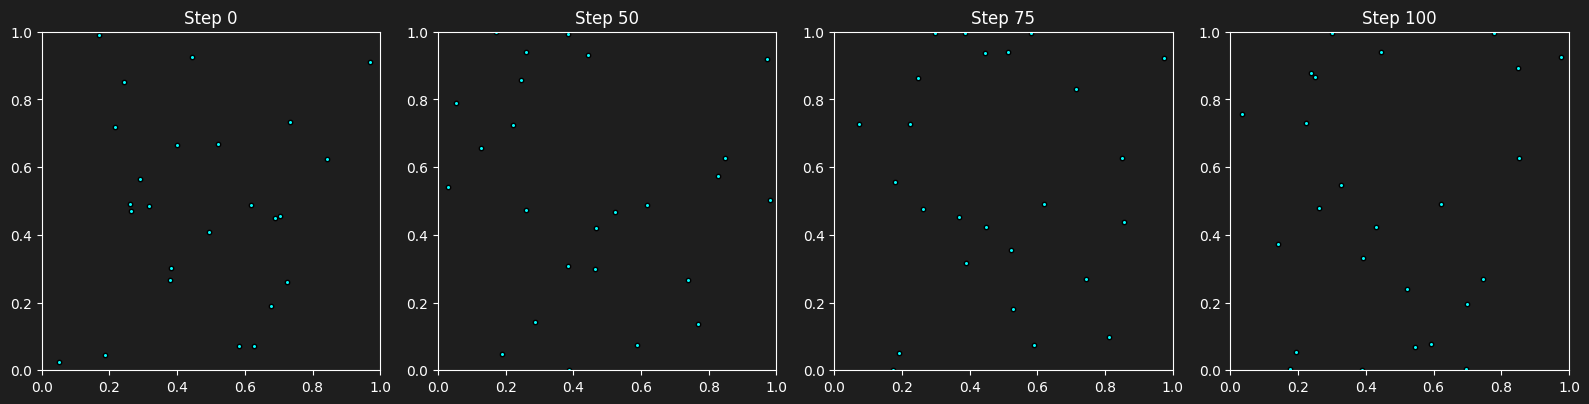

In [20]:
import matplotlib.pyplot as plt

def plot_generation_snapshots(traj, steps=[0, 50, 100, -1], figsize=(16, 4)):
    """
    Plot static snapshots of the generated trajectory at selected timesteps.
    """
    fig, axes = plt.subplots(1, len(steps), figsize=figsize)
    for i, s in enumerate(steps):
        pos = traj[s, :, :2]
        axes[i].scatter(pos[:, 0], pos[:, 1], s=10, c="cyan", edgecolor="k")
        axes[i].set_title(f"Step {s}")
        axes[i].set_xlim(0, 1)
        axes[i].set_ylim(0, 1)
        axes[i].set_aspect("equal")
    plt.tight_layout()
    plt.show()
device = "cuda" if torch.cuda.is_available() else "cpu"

data = validation_dataset[0].to(device)
x0 = data.y
edge_index = data.edge_index

traj = generate_edgegnn_x0_once(VF_x0, x0, edge_index, n_steps=100, sigma=0.01, dt=0.01, L=1.0, device=device)

plot_generation_snapshots(traj, steps=[0, 50, 75, 100])



Trajectory generation from a valid starting point

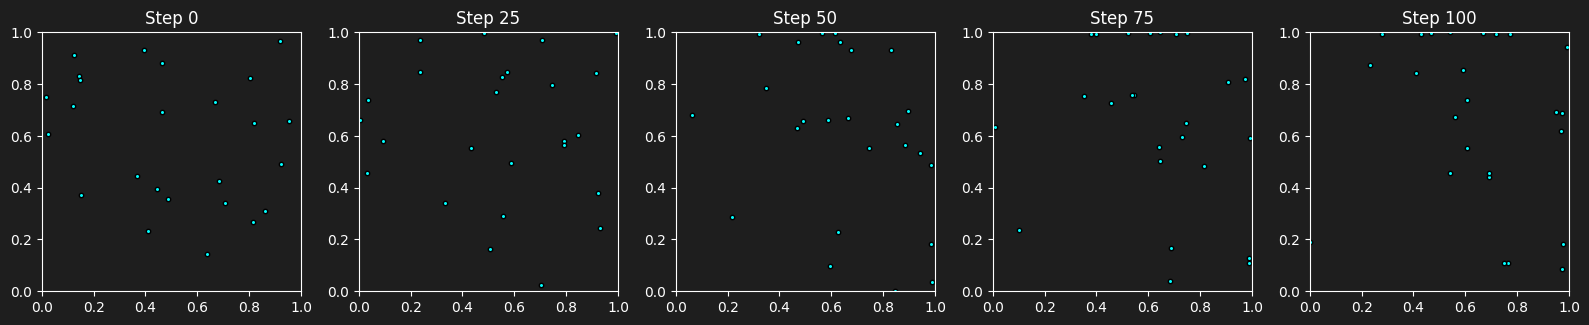

Saved rollout animation → output/boids_rollout.gif


In [21]:
@torch.no_grad()
def rollout_edgegnn(VF, x_init, edge_index, n_steps=100, dt=0.01, L=1.0, device="cuda"):
    """
    Rollout the learned EdgeGNNVectorField_X1Conditioned model for n_steps timesteps.
    Args:
        VF: trained vector field model
        x_init: [N, D] initial state (positions + velocities)
        edge_index: [2, E] edge connectivity
        n_steps: number of rollout steps
        dt: integration step size
        L: periodic box size
        device: device for computation
    Returns:
        traj: [n_steps+1, N, D] tensor of trajectory
    """
    VF.eval()
    VF = VF.to(device)
    x = x_init.to(device)
    x0 = x_init.to(device)
    edge_index = edge_index.to(device)

    N, D = x.shape
    coord_dim = 2
    traj = [x.cpu()]

    for t in range(n_steps):
        t_val = (t / n_steps)
        t_tensor = torch.full((N, 1), t_val, device=device)

        v = VF(x, x0, edge_index, t_tensor)  # Conditioned on current state

        x = x + dt * v

        x[:, :coord_dim] = x[:, :coord_dim] % L

        traj.append(x.cpu())

    traj = torch.stack(traj)  # [n_steps+1, N, D]
    return traj
import matplotlib.pyplot as plt

def plot_rollout_snapshots(traj, steps=[0, 25, 50, 75, 100], L=1.0):
    fig, axes = plt.subplots(1, len(steps), figsize=(16, 4))
    for i, s in enumerate(steps):
        pos = traj[s, :, :2]
        axes[i].scatter(pos[:, 0], pos[:, 1], s=10, c="cyan", edgecolor="k")
        axes[i].set_title(f"Step {s}")
        axes[i].set_xlim(0, L)
        axes[i].set_ylim(0, L)
        axes[i].set_aspect("equal")
    plt.tight_layout()
    plt.show()
import matplotlib.animation as animation
import os

def animate_rollout(traj, output_path="output/rollout.gif", L=1.0):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    fig, ax = plt.subplots(figsize=(5, 5))
    scat = ax.scatter([], [], s=15, c="cyan", edgecolor="k")

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.set_title("Rollout of Learned Dynamics")

    def update(frame):
        pos = traj[frame, :, :2]
        scat.set_offsets(pos)
        ax.set_title(f"Step {frame}/{len(traj)-1}")
        return scat,

    ani = animation.FuncAnimation(fig, update, frames=len(traj), interval=100, blit=True)
    ani.save(output_path, writer="pillow", fps=15)
    plt.close(fig)
    print(f"Saved rollout animation → {output_path}")
device = "cuda" if torch.cuda.is_available() else "cpu"

data = validation_dataset[0].to(device)
x_init = data.x
edge_index = data.edge_index

#traj_rollout = rollout_edgegnn(VF_x0, x_init, edge_index, n_steps=100, dt=0.01, L=1.0, device=device)

steps = 101
dt = 0.01
steps_per_block = 100
x_current = x_init
traj_full = []

for _ in range(steps):
    traj_block = rollout_edgegnn(VF_x0, x_current, edge_index, n_steps=steps_per_block, dt=dt)
    traj_full.append(traj_block[-1]) 
    x_current = traj_block[-1]

traj_full = torch.stack(traj_full) 


plot_rollout_snapshots(traj_full, steps=[0, 25, 50, 75, 100])

animate_rollout(traj_full, output_path="output/boids_rollout.gif")


KL-divergences

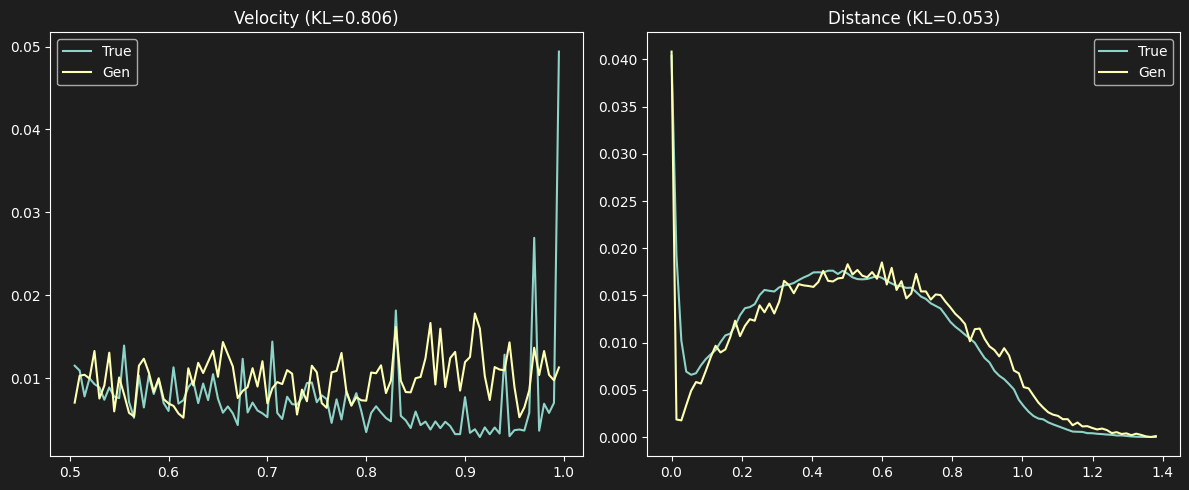

KL (vel): 0.8062
KL (dist): 0.0527


In [22]:
kl_vel, kl_dist = evaluate_edgegnn_x0(VF_x0, validation_dataset)
